# ConvOccNet for Synthetic Peptides
Implementation from: https://github.com/autonomousvision/convolutional_occupancy_networks

**Paper:** "Convolutional Occupancy Networks" (Peng et al., ECCV 2020)

**Architecture:**
- **Encoder**: 3D UNet with multi-scale feature extraction (3 levels)
- **Decoder**: Local decoder with ResNet FC blocks
- **Features**: Trilinear interpolation from 3D feature grid
- **Training**: Query-based occupancy prediction



In [1]:
import importlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import distributions as dist
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import glob
from torch.utils.data import Dataset, DataLoader

import synthetic_peptides_dataset
importlib.reload(synthetic_peptides_dataset)
from synthetic_peptides_dataset import SyntheticPeptidesDataset

In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

## ConvOccNet Architecture Components

In [3]:
# UTILITY FUNCTIONS

def normalize_3d_coordinate(p, padding=0.1):
    """Normalize coordinate to [0, 1] for unit cube experiments.
    
    Args:
        p (tensor): point coordinates
        padding (float): padding parameter, so [-0.5, 0.5] -> [-0.55, 0.55]
    """
    p_nor = p / (1 + padding + 1e-4)  # (-0.5, 0.5)
    p_nor = p_nor + 0.5  # range (0, 1)
    # Handle outliers
    p_nor = torch.clamp(p_nor, min=0.0, max=1.0 - 1e-4)
    return p_nor


# RESNET BLOCKS (from src/layers.py)

class ResnetBlockFC(nn.Module):
    """Fully connected ResNet Block.
    
    Args:
        size_in (int): input dimension
        size_out (int): output dimension
        size_h (int): hidden dimension
    """
    def __init__(self, size_in, size_out=None, size_h=None):
        super().__init__()
        if size_out is None:
            size_out = size_in
        if size_h is None:
            size_h = min(size_in, size_out)
        
        self.size_in = size_in
        self.size_h = size_h
        self.size_out = size_out
        
        self.fc_0 = nn.Linear(size_in, size_h)
        self.fc_1 = nn.Linear(size_h, size_out)
        self.actvn = nn.ReLU()
        
        if size_in == size_out:
            self.shortcut = None
        else:
            self.shortcut = nn.Linear(size_in, size_out, bias=False)
        
        # Initialize last layer to zero
        nn.init.zeros_(self.fc_1.weight)
    
    def forward(self, x):
        net = self.fc_0(self.actvn(x))
        dx = self.fc_1(self.actvn(net))
        
        if self.shortcut is not None:
            x_s = self.shortcut(x)
        else:
            x_s = x
        
        return x_s + dx

In [4]:
# 3D UNET ENCODER

def conv3d(in_channels, out_channels, kernel_size, bias, padding=1):
    return nn.Conv3d(in_channels, out_channels, kernel_size, padding=padding, bias=bias)

class SingleConv(nn.Module):
    """Basic conv block: GroupNorm + Conv3d + ReLU"""
    def __init__(self, in_channels, out_channels, kernel_size=3, order='gcr', num_groups=8, padding=1):
        super().__init__()
        
        modules = []
        for i, char in enumerate(order):
            if char == 'g':
                # Check if GroupNorm is before or after Conv
                is_before_conv = i < order.index('c')
                num_channels = in_channels if is_before_conv else out_channels
                
                # Reduce num_groups if we have fewer channels
                if num_channels < num_groups:
                    num_groups = 1
                
                # Ensure divisibility
                assert num_channels % num_groups == 0, \
                    f'num_channels={num_channels} must be divisible by num_groups={num_groups}'
                
                modules.append(nn.GroupNorm(num_groups=num_groups, num_channels=num_channels))
            elif char == 'c':
                bias = 'g' not in order
                modules.append(conv3d(in_channels, out_channels, kernel_size, bias=bias, padding=padding))
            elif char == 'r':
                modules.append(nn.ReLU(inplace=True))
        
        self.conv = nn.Sequential(*modules)
    
    def forward(self, x):
        return self.conv(x)

class DoubleConv(nn.Module):
    """Two consecutive SingleConv layers"""
    def __init__(self, in_channels, out_channels, encoder, kernel_size=3, order='gcr', num_groups=8):
        super().__init__()
        
        if encoder:
            conv1_in = in_channels
            conv1_out = out_channels // 2
            if conv1_out < in_channels:
                conv1_out = in_channels
            conv2_in, conv2_out = conv1_out, out_channels
        else:
            conv1_in, conv1_out = in_channels, out_channels
            conv2_in, conv2_out = out_channels, out_channels
        
        self.conv1 = SingleConv(conv1_in, conv1_out, kernel_size, order, num_groups)
        self.conv2 = SingleConv(conv2_in, conv2_out, kernel_size, order, num_groups)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        return x

class Encoder(nn.Module):
    """Single encoder module: optional pooling + DoubleConv"""
    def __init__(self, in_channels, out_channels, conv_kernel_size=3, apply_pooling=True,
                 pool_kernel_size=(2,2,2), pool_type='max', conv_layer_order='gcr', num_groups=8):
        super().__init__()
        
        if apply_pooling:
            if pool_type == 'max':
                self.pooling = nn.MaxPool3d(kernel_size=pool_kernel_size)
            else:
                self.pooling = nn.AvgPool3d(kernel_size=pool_kernel_size)
        else:
            self.pooling = None
        
        self.basic_module = DoubleConv(in_channels, out_channels, encoder=True,
                                       kernel_size=conv_kernel_size, order=conv_layer_order,
                                       num_groups=num_groups)
    
    def forward(self, x):
        if self.pooling is not None:
            x = self.pooling(x)
        x = self.basic_module(x)
        return x

class UNet3DEncoder(nn.Module):
    """3D UNet Encoder for ConvOccNet
    
    Args:
        in_channels (int): number of input channels
        f_maps (int or tuple): number of feature maps at each level
        num_levels (int): number of encoding levels
        layer_order (str): order of operations in conv block
        num_groups (int): number of groups for GroupNorm
    """
    def __init__(self, in_channels=1, f_maps=32, num_levels=4, layer_order='gcr', num_groups=8):
        super().__init__()
        
        if isinstance(f_maps, int):
            # Generate feature maps: f_maps, f_maps*2, f_maps*4, ...
            f_maps = [f_maps * 2**k for k in range(num_levels)]
        
        # Create encoder path
        encoders = []
        for i, out_feature_num in enumerate(f_maps):
            if i == 0:
                encoder = Encoder(in_channels, out_feature_num, apply_pooling=False,
                                conv_layer_order=layer_order, num_groups=num_groups)
            else:
                encoder = Encoder(f_maps[i-1], out_feature_num, apply_pooling=True,
                                conv_layer_order=layer_order, num_groups=num_groups)
            encoders.append(encoder)
        
        self.encoders = nn.ModuleList(encoders)
    
    def forward(self, x):
        """Returns the deepest feature map (last encoder output)"""
        for encoder in self.encoders:
            x = encoder(x)
        return x

print("✓ 3D UNet Encoder loaded")

✓ 3D UNet Encoder loaded


In [5]:
# LOCAL DECODER

class LocalDecoder(nn.Module):
    """Decoder that conditions on 3D grid local features.
    
    Args:
        dim (int): input point dimension
        c_dim (int): dimension of latent conditioned code
        hidden_size (int): hidden size of decoder network
        n_blocks (int): number of ResNetBlockFC layers
        leaky (bool): whether to use leaky ReLUs
        sample_mode (str): sampling feature strategy (bilinear or nearest)
        padding (float): padding parameter for unit cube
    """
    def __init__(self, dim=3, c_dim=128, hidden_size=256, n_blocks=5, 
                 leaky=False, sample_mode='bilinear', padding=0.1):
        super().__init__()
        self.c_dim = c_dim
        self.n_blocks = n_blocks
        
        if c_dim != 0:
            self.fc_c = nn.ModuleList([
                nn.Linear(c_dim, hidden_size) for i in range(n_blocks)
            ])
        
        self.fc_p = nn.Linear(dim, hidden_size)
        
        self.blocks = nn.ModuleList([
            ResnetBlockFC(hidden_size) for i in range(n_blocks)
        ])
        
        self.fc_out = nn.Linear(hidden_size, 1)
        
        if not leaky:
            self.actvn = F.relu
        else:
            self.actvn = lambda x: F.leaky_relu(x, 0.2)
        
        self.sample_mode = sample_mode
        self.padding = padding
    
    def sample_grid_feature(self, p, c):
        """Sample features at query points using trilinear interpolation.
        
        Args:
            p: query points [batch, num_points, 3] in range [-0.5, 0.5]
            c: feature grid [batch, c_dim, D, H, W]
        
        Returns:
            Sampled features [batch, c_dim, num_points]
        """
        p_nor = normalize_3d_coordinate(p.clone(), padding=self.padding)  # to [0, 1]
        p_nor = p_nor[:, :, None, None].float()  # [B, N, 1, 1, 3]
        vgrid = 2.0 * p_nor - 1.0  # to [-1, 1] for grid_sample
        
        # Trilinear interpolation (mode='bilinear' works for 3D)
        c = F.grid_sample(c, vgrid, padding_mode='border', 
                         align_corners=True, mode=self.sample_mode)
        c = c.squeeze(-1).squeeze(-1)  # [B, C, N]
        return c
    
    def forward(self, p, c_grid, **kwargs):
        """Forward pass.
        
        Args:
            p: query points [batch, num_points, 3]
            c_grid: feature grid dictionary {'grid': feature_tensor}
        
        Returns:
            Occupancy logits [batch, num_points]
        """
        # Sample features at query points
        if self.c_dim != 0:
            c = self.sample_grid_feature(p, c_grid['grid'])
            c = c.transpose(1, 2)  # [B, N, C]
        
        p = p.float()
        net = self.fc_p(p)
        
        for i in range(self.n_blocks):
            if self.c_dim != 0:
                net = net + self.fc_c[i](c)
            net = self.blocks[i](net)
        
        out = self.fc_out(self.actvn(net))
        out = out.squeeze(-1)
        
        return out

print("✓ Local Decoder loaded")

✓ Local Decoder loaded


In [6]:
# CONVOLUTIONAL OCCUPANCY NETWORK

class ConvolutionalOccupancyNetwork(nn.Module):
    """Convolutional Occupancy Network.
    
    Args:
        decoder (nn.Module): decoder network
        encoder (nn.Module): encoder network
        device: torch device
    """
    def __init__(self, decoder, encoder=None, device=None):
        super().__init__()
        
        self.decoder = decoder
        self.encoder = encoder if encoder is not None else None
        self._device = device
        
        if device is not None:
            self.to(device)
    
    def forward(self, p, inputs, **kwargs):
        """Forward pass.
        
        Args:
            p: query points [batch, num_points, 3]
            inputs: input voxel grid [batch, 1, D, H, W]
        
        Returns:
            Bernoulli distribution over occupancy
        """
        c = self.encode_inputs(inputs)
        p_r = self.decode(p, c, **kwargs)
        return p_r
    
    def encode_inputs(self, inputs):
        """Encode the input.
        
        Args:
            inputs: input voxel grid
        
        Returns:
            Feature dictionary
        """
        if self.encoder is not None:
            c = self.encoder(inputs)
            # Package as dictionary for decoder
            c = {'grid': c}
        else:
            c = {'grid': torch.empty(inputs.size(0), 0)}
        return c
    
    def decode(self, p, c, **kwargs):
        """Decode query points to occupancy probabilities.
        
        Args:
            p: query points
            c: latent feature code
        
        Returns:
            Bernoulli distribution
        """
        logits = self.decoder(p, c, **kwargs)
        p_r = dist.Bernoulli(logits=logits)
        return p_r
    
    def to(self, device):
        model = super().to(device)
        model._device = device
        return model

print("✓ ConvOccNet main model loaded")

✓ ConvOccNet main model loaded


## Dataset for Peptides

In [7]:
def points_to_voxels(points, grid_size=32):
    """Convert peptide centroid point cloud to occupancy grid."""
    voxel_grid = np.zeros((grid_size, grid_size, grid_size), dtype=np.float32)

    points_norm = points + 0.5  # from [-0.5, 0.5] -> [0, 1]
    indices = (points_norm * (grid_size - 1)).astype(int)
    indices = np.clip(indices, 0, grid_size - 1)

    voxel_grid[indices[:, 0], indices[:, 1], indices[:, 2]] = 1.0
    return voxel_grid


class PeptideDataset(Dataset):
    """Dataset for peptide assemblies using one centroid point per peptide.

    Returns voxel grid, query points in [-0.5, 0.5]^3, and occupancy labels
    computed from peptide-centroid distances.
    """

    def __init__(
        self,
        data_path='./data/synthetic_peptides',
        grid_size=64,
        num_query_points=2000,
        num_files=None,
        structure_types=None,
        occupancy_threshold=0.02,
        target_num_points=None,
        seed=None,
    ):
        self.grid_size = grid_size
        self.num_query_points = num_query_points
        self.occupancy_threshold = occupancy_threshold

        self.base_dataset = SyntheticPeptidesDataset(
            data_path=data_path,
            structure_types=structure_types,
            num_files=num_files,
            target_num_points=target_num_points,
            normalize=True,
            return_peptide_ids=True,
            seed=seed,
        )

        self.files = self.base_dataset.files
        self.file_types = self.base_dataset.file_types

        print(
            f"Centroid dataset ready: {len(self.files)} files, "
            f"grid={grid_size}^3, query_points={num_query_points}, "
            f"threshold={occupancy_threshold}"
        )

    def get_file_type(self, idx):
        return self.file_types[self.files[idx]]

    def __len__(self):
        return len(self.base_dataset)

    def get_centroid_points(self, idx):
        sample = self.base_dataset[idx]
        centroid_points = sample['points'].cpu().numpy()
        peptide_ids = sample['peptide_ids'].cpu().numpy()
        mask = sample['mask'].cpu().numpy().astype(bool)
        return centroid_points[mask], peptide_ids[mask]

    def __getitem__(self, idx):
        try:
            centroid_points, _ = self.get_centroid_points(idx)
            if len(centroid_points) == 0:
                raise ValueError('No peptide centroids found')

            voxel_grid = points_to_voxels(centroid_points, self.grid_size)
            voxel_tensor = torch.tensor(voxel_grid, dtype=torch.float32).unsqueeze(0)

            query_points = torch.rand(self.num_query_points, 3) - 0.5
            centroid_tensor = torch.tensor(centroid_points, dtype=torch.float32)
            dists = torch.cdist(query_points, centroid_tensor)
            min_dists = dists.min(dim=1)[0]
            occupancy = (min_dists < self.occupancy_threshold).float()

            return voxel_tensor, query_points, occupancy

        except Exception as e:
            print(f"Error loading {self.files[idx]}: {e}")
            voxel_tensor = torch.zeros(1, self.grid_size, self.grid_size, self.grid_size)
            query_points = torch.rand(self.num_query_points, 3) - 0.5
            occupancy = torch.zeros(self.num_query_points)
            return voxel_tensor, query_points, occupancy


print('Dataset class defined for peptide-centroid inputs')

Dataset class defined for peptide-centroid inputs


In [8]:
# Quick centroid-dataset smoke test
centroid_preview = PeptideDataset(
    data_path='./data/synthetic_peptides_split/train',
    grid_size=64,
    num_query_points=128,
    num_files=1,
    occupancy_threshold=0.02,
    structure_types=['nanotubes'],
)

centroid_points, centroid_ids = centroid_preview.get_centroid_points(0)
preview_voxel, preview_query, preview_occ = centroid_preview[0]

print('centroid points shape:', centroid_points.shape)
print('unique peptide ids:', len(np.unique(centroid_ids)))
print('voxel shape:', tuple(preview_voxel.shape))
print('query shape:', tuple(preview_query.shape))
print('occupancy shape:', tuple(preview_occ.shape))

Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: nanotubes
Selected files per structure:
  nanotubes: 1/700
Dataset ready: 1 files, target_points=None, normalize=True
Centroid dataset ready: 1 files, grid=64^3, query_points=128, threshold=0.02
centroid points shape: (3000, 3)
unique peptide ids: 3000
voxel shape: (1, 64, 64, 64)
query shape: (128, 3)
occupancy shape: (128,)


## Model Initialization

In [11]:
# Model configuration (matching official defaults)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Encoder: 3D UNet
# Input: 64³ → 32³ → 16³ (final) with 3 levels
# Feature maps: 16 → 32 → 64 channels
encoder = UNet3DEncoder(
    in_channels=1,
    f_maps=16,  # Feature maps: 16, 32, 64
    num_levels=3,  # 3 levels: 64³→64³, 64³→32³, 32³→16³
    layer_order='gcr',
    num_groups=8
)

# Decoder: Local decoder
# Spatial grid: [batch, 64, 16, 16, 16]
decoder = LocalDecoder(
    dim=3,  # Dimensionality of input queries (x,y,z)
    c_dim=64,  # Must match last encoder output (16 * 2^2 = 64)
    hidden_size=256,
    n_blocks=5,
    leaky=False,
    sample_mode='bilinear',
    padding=0.1
)

# Complete model
model = ConvolutionalOccupancyNetwork(
    decoder=decoder,
    encoder=encoder,
    device=device
)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Encoder params: {sum(p.numel() for p in encoder.parameters()):,}")
print(f"Decoder params: {sum(p.numel() for p in decoder.parameters()):,}")


Device: cuda

Model parameters: 849,963
Encoder params: 107,562
Decoder params: 742,401


## Training (Full + Checkpointing)

In [12]:
# Full training loop with validation and checkpointing
import json
from pathlib import Path


# Runtime + data setup

os.environ['CUDA_VISIBLE_DEVICES'] = '3'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Run configuration
RUN_NAME = 'convocc_peptides_2000'  # Change for different runs
TRAIN_DATA_PATH = './data/synthetic_peptides_split/train'
VAL_DATA_PATH = './data/synthetic_peptides_split/val'

GRID_SIZE = 64
NUM_QUERY_POINTS = 2000
OCCUPANCY_THRESHOLD = 0.02
TRAIN_NUM_FILES = 2000
VAL_NUM_FILES = 426

BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS = 500
SAVE_EVERY = 10
VAL_INTERVAL = 10

# Build train/val datasets
dataset = PeptideDataset(
    data_path=TRAIN_DATA_PATH,
    grid_size=GRID_SIZE,
    num_query_points=NUM_QUERY_POINTS,
    num_files=TRAIN_NUM_FILES,
    occupancy_threshold=OCCUPANCY_THRESHOLD,
    structure_types=['nanotubes', 'micelles', 'nanofibers', 'random_aggregates', 'lamellar_sheets'],
)
val_dataset = PeptideDataset(
    data_path=VAL_DATA_PATH,
    grid_size=GRID_SIZE,
    num_query_points=NUM_QUERY_POINTS,
    num_files=VAL_NUM_FILES,
    occupancy_threshold=OCCUPANCY_THRESHOLD,
    structure_types=['nanotubes', 'micelles', 'nanofibers', 'random_aggregates', 'lamellar_sheets'],
)

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=0)

Using device: cuda
Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: nanotubes, micelles, nanofibers, random_aggregates, lamellar_sheets
Selected files per structure:
  nanotubes: 142/700
  micelles: 142/700
  nanofibers: 142/700
  random_aggregates: 1428/7000
  lamellar_sheets: 142/700
Dataset ready: 1996 files, target_points=None, normalize=True
Centroid dataset ready: 1996 files, grid=64^3, query_points=2000, threshold=0.02
Loading centroid dataset from: ./data/synthetic_peptides_split/val
Structure types: nanotubes, micelles, nanofibers, random_aggregates, lamellar_sheets
Selected files per structure:
  nanotubes: 30/150
  micelles: 30/150
  nanofibers: 30/150
  random_aggregates: 304/1500
  lamellar_sheets: 30/150
Dataset ready: 424 files, target_points=None, normalize=True
Centroid dataset ready: 424 files, grid=64^3, query_points=2000, threshold=0.02


Using device: cuda
Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: nanotubes, micelles, nanofibers, random_aggregates, lamellar_sheets
Selected files per structure:
  nanotubes: 142/700
  micelles: 142/700
  nanofibers: 142/700
  random_aggregates: 1428/7000
  lamellar_sheets: 142/700
Dataset ready: 1996 files, target_points=None, normalize=True
Centroid dataset ready: 1996 files, grid=64^3, query_points=2000, threshold=0.02
Loading centroid dataset from: ./data/synthetic_peptides_split/val
Structure types: nanotubes, micelles, nanofibers, random_aggregates, lamellar_sheets
Selected files per structure:
  nanotubes: 30/150
  micelles: 30/150
  nanofibers: 30/150
  random_aggregates: 304/1500
  lamellar_sheets: 30/150
Dataset ready: 424 files, target_points=None, normalize=True
Centroid dataset ready: 424 files, grid=64^3, query_points=2000, threshold=0.02

=== TRAINING SETUP ===
Run name: convocc_peptides_2000
Train samples: 1996
Val samples: 424
B

/tmp/ipykernel_121203/1949207211.py:119: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


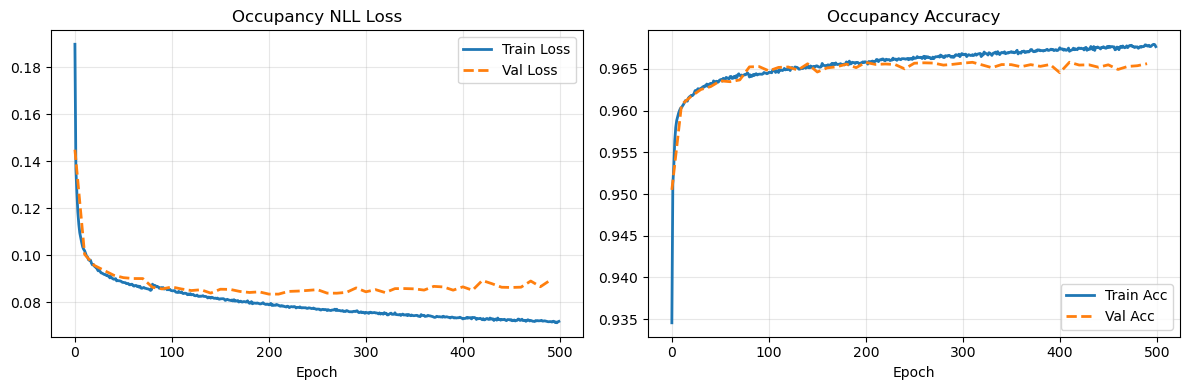


=== FINAL STATUS ===
Run: convocc_peptides_2000
Final train loss: 0.071899
Final val loss: 0.089402
Best val loss: 0.083506


In [ ]:


# Recreate model for clean training
encoder = UNet3DEncoder(
    in_channels=1,
    f_maps=16,
    num_levels=3,
    layer_order='gcr',
    num_groups=8
)
decoder = LocalDecoder(
    dim=3,
    c_dim=64,
    hidden_size=256,
    n_blocks=5,
    leaky=False,
    sample_mode='bilinear',
    padding=0.1
)
model = ConvolutionalOccupancyNetwork(
    decoder=decoder,
    encoder=encoder,
    device=device
)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0.0)

print("\n=== TRAINING SETUP ===")
print(f"Run name: {RUN_NAME}")
print(f"Train samples: {len(dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Epochs: {EPOCHS}")
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")


# Checkpoint setup

checkpoint_dir = Path('checkpoints') / RUN_NAME
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = checkpoint_dir / 'latest.pth'
best_checkpoint_path = checkpoint_dir / 'best.pth'
log_path = checkpoint_dir / 'training_log.json'

config = {
    'run_name': RUN_NAME,
    'train_data_path': TRAIN_DATA_PATH,
    'val_data_path': VAL_DATA_PATH,
    'grid_size': GRID_SIZE,
    'num_query_points': NUM_QUERY_POINTS,
    'occupancy_threshold': OCCUPANCY_THRESHOLD,
    'train_num_files': TRAIN_NUM_FILES,
    'val_num_files': VAL_NUM_FILES,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'epochs': EPOCHS,
    'save_every': SAVE_EVERY,
    'val_interval': VAL_INTERVAL,
    'model_params': sum(p.numel() for p in model.parameters()),
}

start_epoch = 0
losses = []
accs = []
val_losses = []
val_accs = []
best_loss = float('inf')

if checkpoint_path.exists():
    print("\nLoading existing checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    losses = checkpoint.get('losses', [])
    accs = checkpoint.get('accs', [])
    val_losses = checkpoint.get('val_losses', [])
    val_accs = checkpoint.get('val_accs', [])
    best_loss = checkpoint.get('best_loss', min(val_losses) if val_losses else float('inf'))
    print(
        f"Resumed from epoch {start_epoch} | "
        f"last train loss: {losses[-1]:.6f} | best val loss: {best_loss:.6f}"
    )
else:
    print("\nStarting fresh training run")


# Training

try:
    for epoch in range(start_epoch, EPOCHS):
        model.train()
        epoch_loss = 0.0
        epoch_acc = 0.0

        for voxel, query, occ_gt in dataloader:
            voxel = voxel.to(device)
            query = query.to(device)
            occ_gt = occ_gt.to(device)

            optimizer.zero_grad()
            p_r = model(query, voxel)

            # Bernoulli NLL loss over occupancy labels
            loss = -p_r.log_prob(occ_gt).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            with torch.no_grad():
                pred = (p_r.probs > 0.5).float()
                acc = (pred == occ_gt).float().mean()
                epoch_acc += acc.item()

        avg_loss = epoch_loss / len(dataloader)
        avg_acc = epoch_acc / len(dataloader)
        losses.append(avg_loss)
        accs.append(avg_acc)

        val_avg_loss = None
        val_avg_acc = None

        if epoch % VAL_INTERVAL == 0:
            model.eval()
            val_epoch_loss = 0.0
            val_epoch_acc = 0.0

            with torch.no_grad():
                for voxel, query, occ_gt in val_dataloader:
                    voxel = voxel.to(device)
                    query = query.to(device)
                    occ_gt = occ_gt.to(device)

                    p_r = model(query, voxel)
                    val_loss = -p_r.log_prob(occ_gt).mean()

                    val_epoch_loss += val_loss.item()
                    pred = (p_r.probs > 0.5).float()
                    acc = (pred == occ_gt).float().mean()
                    val_epoch_acc += acc.item()

            val_avg_loss = val_epoch_loss / len(val_dataloader)
            val_avg_acc = val_epoch_acc / len(val_dataloader)
            val_losses.append(val_avg_loss)
            val_accs.append(val_avg_acc)

            if val_avg_loss < best_loss:
                best_loss = val_avg_loss
                torch.save(
                    {
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'encoder_state_dict': encoder.state_dict(),
                        'decoder_state_dict': decoder.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'losses': losses,
                        'accs': accs,
                        'val_losses': val_losses,
                        'val_accs': val_accs,
                        'config': config,
                        'best_loss': best_loss,
                    },
                    best_checkpoint_path,
                )

        if epoch % VAL_INTERVAL == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"Train Loss: {avg_loss:.6f}, Acc: {avg_acc:.4f} | "
                f"Val Loss: {val_avg_loss:.6f}, Acc: {val_avg_acc:.4f}"
            )
        else:
            print(f"Epoch {epoch:4d} | Train Loss: {avg_loss:.6f}, Acc: {avg_acc:.4f}")

        if (epoch + 1) % SAVE_EVERY == 0 or epoch == EPOCHS - 1:
            epoch_folder = checkpoint_dir / f'checkpoint_epoch_{epoch + 1}'
            epoch_folder.mkdir(exist_ok=True)

            state = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'encoder_state_dict': encoder.state_dict(),
                'decoder_state_dict': decoder.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'losses': losses,
                'accs': accs,
                'val_losses': val_losses,
                'val_accs': val_accs,
                'config': config,
                'best_loss': best_loss,
            }

            torch.save(state, epoch_folder / 'model.pth')
            torch.save(state, checkpoint_path)

            with open(epoch_folder / 'training_log.json', 'w') as f:
                json.dump(
                    {
                        'epoch': epoch,
                        'losses': losses,
                        'accs': accs,
                        'val_losses': val_losses,
                        'val_accs': val_accs,
                        'config': config,
                        'best_loss': best_loss,
                    },
                    f,
                    indent=2,
                )

            with open(log_path, 'w') as f:
                json.dump(
                    {
                        'epoch': epoch,
                        'losses': losses,
                        'accs': accs,
                        'val_losses': val_losses,
                        'val_accs': val_accs,
                        'config': config,
                        'best_loss': best_loss,
                    },
                    f,
                    indent=2,
                )

    final_val_str = f", Final Val Loss: {val_losses[-1]:.6f}" if val_losses else ""
    print(
        f"\nTraining complete. Final Train Loss: {losses[-1]:.6f}"
        f"{final_val_str}, Best Val Loss: {best_loss:.6f}"
    )

except KeyboardInterrupt:
    print(f"\nInterrupted at epoch {epoch}. Saving checkpoint...")
    state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'encoder_state_dict': encoder.state_dict(),
        'decoder_state_dict': decoder.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'losses': losses,
        'accs': accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'config': config,
        'best_loss': best_loss,
    }
    torch.save(state, checkpoint_path)
    with open(log_path, 'w') as f:
        json.dump(
            {
                'epoch': epoch,
                'losses': losses,
                'accs': accs,
                'val_losses': val_losses,
                'val_accs': val_accs,
                'config': config,
                'best_loss': best_loss,
            },
            f,
            indent=2,
        )
    print(f"Checkpoint saved. Resume from epoch {epoch + 1}")

except Exception as e:
    print(f"\nError at epoch {epoch}: {e}. Saving checkpoint...")
    try:
        state = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'encoder_state_dict': encoder.state_dict(),
            'decoder_state_dict': decoder.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'losses': losses,
            'accs': accs,
            'val_losses': val_losses,
            'val_accs': val_accs,
            'config': config,
            'best_loss': best_loss,
        }
        torch.save(state, checkpoint_path)
        with open(log_path, 'w') as f:
            json.dump(
                {
                    'epoch': epoch,
                    'losses': losses,
                    'accs': accs,
                    'val_losses': val_losses,
                    'val_accs': val_accs,
                    'config': config,
                    'best_loss': best_loss,
                },
                f,
                indent=2,
            )
        print(f"Checkpoint saved. Resume from epoch {epoch + 1}")
    except Exception:
        pass
    raise

# Quick training curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(losses, label='Train Loss', linewidth=2)
if val_losses:
    val_epochs = list(range(0, len(losses), VAL_INTERVAL))[:len(val_losses)]
    ax[0].plot(val_epochs, val_losses, '--', label='Val Loss', linewidth=2)
ax[0].set_title('Occupancy NLL Loss')
ax[0].set_xlabel('Epoch')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(accs, label='Train Acc', linewidth=2)
if val_accs:
    val_epochs = list(range(0, len(losses), VAL_INTERVAL))[:len(val_accs)]
    ax[1].plot(val_epochs, val_accs, '--', label='Val Acc', linewidth=2)
ax[1].set_title('Occupancy Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

print("\n=== FINAL STATUS ===")
print(f"Run: {RUN_NAME}")
print(f"Final train loss: {losses[-1]:.6f}")
if val_losses:
    print(f"Final val loss: {val_losses[-1]:.6f}")
print(f"Best val loss: {best_loss:.6f}")

Loaded training log: checkpoints/convocc_peptides_2000/training_log.json
Run: convocc_peptides_2000
Train epochs logged: 500 | Val points logged: 50 | Val interval: 10


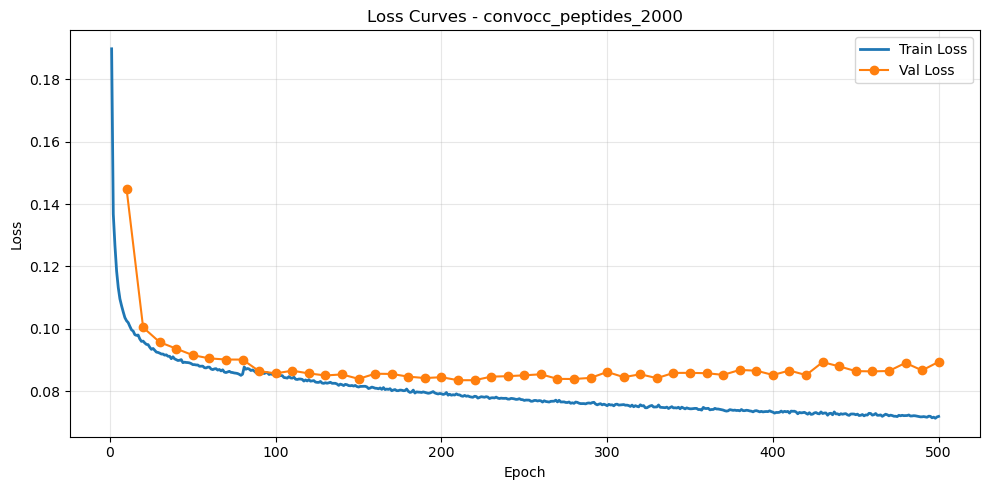

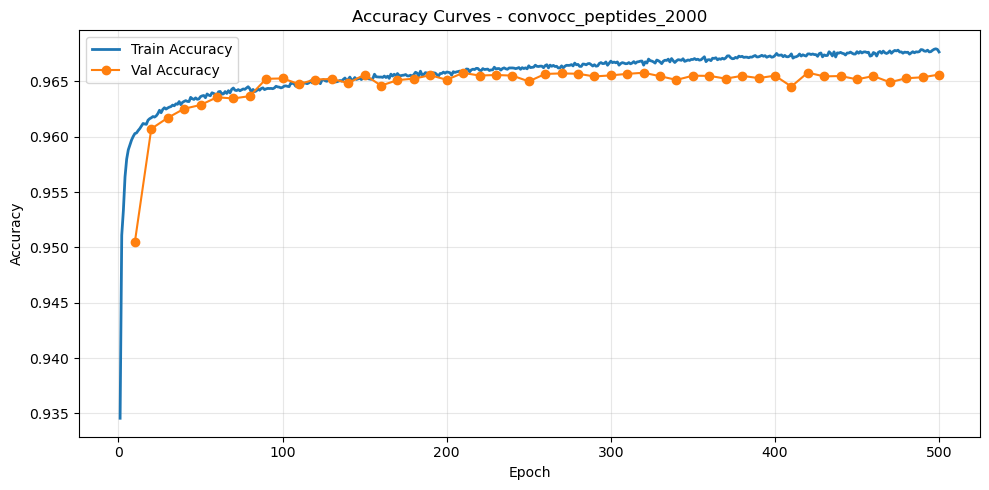

In [13]:
# Training curves for the loaded run
import json

RUN_NAME = 'convocc_peptides_2000'
ckpt_dir = Path("checkpoints") / RUN_NAME

log_path = ckpt_dir / "training_log.json"
if not log_path.exists():
    raise FileNotFoundError(f"No training log found for run '{RUN_NAME}' at {log_path}")

with open(log_path, "r") as f:
    training_log = json.load(f)

train_losses = np.asarray(training_log.get("losses", []), dtype=float)
val_losses = np.asarray(training_log.get("val_losses", []), dtype=float)
train_accs = np.asarray(training_log.get("accs", []), dtype=float)
val_accs = np.asarray(training_log.get("val_accs", []), dtype=float)

if train_losses.size == 0:
    raise ValueError(f"Run '{RUN_NAME}' log does not contain training losses.")

config = training_log.get("config", {})
val_interval = int(config.get("val_interval", 0)) if isinstance(config, dict) else 0
if val_interval <= 0:
    val_interval = max(1, int(round(len(train_losses) / max(1, len(val_losses))))) if len(val_losses) else 1

train_epochs = np.arange(1, len(train_losses) + 1)
val_epochs = np.arange(1, len(val_losses) + 1) * val_interval

print(f"Loaded training log: {log_path}")
print(f"Run: {RUN_NAME}")
print(f"Train epochs logged: {len(train_losses)} | Val points logged: {len(val_losses)} | Val interval: {val_interval}")

# Loss plot (train + val)
plt.figure(figsize=(10, 5))
plt.plot(train_epochs, train_losses, label="Train Loss", linewidth=2)
if len(val_losses) > 0:
    plt.plot(val_epochs, val_losses, label="Val Loss", marker="o", linewidth=1.5)
plt.title(f"Loss Curves - {RUN_NAME}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy plot (train + val)
plt.figure(figsize=(10, 5))
if len(train_accs) > 0:
    plt.plot(train_epochs[:len(train_accs)], train_accs, label="Train Accuracy", linewidth=2)
if len(val_accs) > 0:
    val_acc_epochs = np.arange(1, len(val_accs) + 1) * val_interval
    plt.plot(val_acc_epochs, val_accs, label="Val Accuracy", marker="o", linewidth=1.5)
plt.title(f"Accuracy Curves - {RUN_NAME}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation & Visualization

In [69]:
# Evaluation
model.eval()

test_idx = 0
voxel, _, _ = dataset[test_idx]
voxel = voxel.unsqueeze(0).to(device)

print("=== GENERATING HIGH-RES RECONSTRUCTION ===")
resolution = 64
x = torch.linspace(-0.5, 0.5, resolution)
y = torch.linspace(-0.5, 0.5, resolution)
z = torch.linspace(-0.5, 0.5, resolution)
grid_x, grid_y, grid_z = torch.meshgrid(x, y, z, indexing='ij')
query_grid = torch.stack([grid_x.flatten(), grid_y.flatten(), grid_z.flatten()], dim=1)

print(f"Querying {resolution}³ = {query_grid.shape[0]:,} points...")

# Predict in batches
batch_size = 8192
occupancy_pred = []

with torch.no_grad():
    for i in range(0, query_grid.shape[0], batch_size):
        query_batch = query_grid[i:i+batch_size].unsqueeze(0).to(device)
        p_r = model(query_batch, voxel)
        occupancy_pred.append(p_r.probs)

occupancy_pred = torch.cat(occupancy_pred, dim=1)
occupancy_pred = occupancy_pred.squeeze(0).cpu()
occupancy_grid = occupancy_pred.reshape(resolution, resolution, resolution)

print(f"Complete!")
print(f"Mean occupancy: {occupancy_grid.mean():.4f}")
print(f"Occupied (>0.5): {(occupancy_grid > 0.5).sum().item()}/{occupancy_grid.numel()}")

=== GENERATING HIGH-RES RECONSTRUCTION ===
Querying 64³ = 262,144 points...
Complete!
Mean occupancy: 0.0334
Occupied (>0.5): 8476/262144


In [ ]:
# 3D Visualization
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    subplot_titles=(f'Input (64³)', f'Ground Truth Peptide Centroids', f'ConvOccNet Output (64³)'),
    horizontal_spacing=0.03
)

# Input voxelized centroid cloud
input_np = voxel.cpu().squeeze().numpy()
idx_in = np.where(input_np > 0.5)
fig.add_trace(
    go.Scatter3d(
        x=idx_in[0], y=idx_in[1], z=idx_in[2],
        mode='markers',
        marker=dict(size=3, color='blue', opacity=0.6),
        name='Input'
    ),
    row=1, col=1
)

# Ground truth centroid cloud
gt_points, _ = dataset.get_centroid_points(test_idx)
gt_points_scaled = (gt_points + 0.5) * (input_np.shape[0] - 1)
gt_points_scaled = np.clip(gt_points_scaled, 0, input_np.shape[0] - 1)

fig.add_trace(
    go.Scatter3d(
        x=gt_points_scaled[:, 0], y=gt_points_scaled[:, 1], z=gt_points_scaled[:, 2],
        mode='markers',
        marker=dict(size=4, color='green', opacity=0.85),
        name='Ground Truth'
    ),
    row=1, col=2
)

# Output
output_np = occupancy_grid.numpy()
idx_out = np.where(output_np > 0.5)
fig.add_trace(
    go.Scatter3d(
        x=idx_out[0], y=idx_out[1], z=idx_out[2],
        mode='markers',
        marker=dict(size=2, color='red', opacity=0.6),
        name='Output'
    ),
    row=1, col=3
)

fig.update_layout(
    title='ConvOccNet: Input vs Peptide-Centroid Ground Truth vs Prediction',
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='cube'),
    scene2=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='cube'),
    scene3=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='cube'),
    height=500,
    showlegend=False
)
fig.show()

print(f'\nDiagnostics:')
print(f'Ground truth peptides: {len(gt_points)}')
print(f'Input occupied voxels: {len(idx_in[0])}')
print(f'Predicted occupied: {(occupancy_grid > 0.5).sum().item()}/{occupancy_grid.numel()} ({100*(occupancy_grid > 0.5).float().mean().item():.1f}%)')

# 2D Projections
fig_2d = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Input (Max Proj)', 'Output (Max Proj)')
)

input_proj = np.max(input_np, axis=2)
fig_2d.add_trace(
    go.Heatmap(z=input_proj, colorscale='Blues', showscale=False),
    row=1, col=1
)

output_proj = np.max(output_np, axis=2)
fig_2d.add_trace(
    go.Heatmap(z=output_proj, colorscale='Reds', showscale=False),
    row=1, col=2
)

fig_2d.update_layout(title='2D Projections', height=350)
fig_2d.show()


Diagnostics:
Ground truth peptides: 3000
Input occupied voxels: 2462
Predicted occupied: 8476/262144 (3.2%)


: 

In [ ]:
# Optional standalone export for deployment/inference
from pathlib import Path

export_dir = Path('checkpoints') / RUN_NAME
export_dir.mkdir(parents=True, exist_ok=True)
export_path = export_dir / 'convocc_net_export.pth'

torch.save(
    {
        'model_state_dict': model.state_dict(),
        'encoder_state_dict': encoder.state_dict(),
        'decoder_state_dict': decoder.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'losses': losses,
        'accs': accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'config': {
            'encoder_f_maps': 16,
            'encoder_num_levels': 3,
            'decoder_c_dim': 64,
            'decoder_hidden_size': 256,
            'decoder_n_blocks': 5,
            'grid_size': dataset.grid_size,
            'run_name': RUN_NAME,
        },
        'best_loss': best_loss,
    },
    export_path,
 )

print(f"Saved export checkpoint: {export_path}")
print("\n=== SUMMARY ===")
print("Implementation: Official ConvOccNet (Peng et al., ECCV 2020)")
print("Architecture: 3D UNet Encoder + Local ResNet Decoder")
print(f"Input resolution: {dataset.grid_size}^3")
print(f"Output resolution: {resolution}^3 (arbitrary)")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Final train loss: {losses[-1]:.6f}")
if val_losses:
    print(f"Final val loss: {val_losses[-1]:.6f}")
print(f"Best val loss: {best_loss:.6f}")